<a href="https://www.kaggle.com/code/lalit7881/airline-satisfaction-eda-94-23?scriptVersionId=344199626" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv")

In [3]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,25,18.0,False
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,1,1,6.0,False
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,5,0,0.0,True
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,2,11,9.0,False
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,0,0.0,True


In [4]:
df.tail()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
129875,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,4,3,2,4,4,4,0,0.0,False
129876,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,4,5,5,5,4,0,0.0,True
129877,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,2,4,3,4,5,2,0,0.0,False
129878,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,4,3,2,5,4,4,0,0.0,True
129879,Female,Loyal Customer,42,Personal Travel,Eco,264,2,5,2,5,...,2,1,1,2,1,1,1,0,0.0,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    1298

In [6]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.286326,14.713713,15.091129
std,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.313682,38.071126,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [7]:
df.dtypes

Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfaction                            bool
dtype: obj

In [8]:
df.shape

(129880, 22)

In [9]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [10]:
df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Gender                                  2
Customer Type                           2
Age                                    75
Type of Travel                          2
Class                                   3
Flight Distance                      3821
Inflight wifi service                   6
Departure/Arrival time convenient       6
Ease of Online booking                  6
Gate location                           6
Food and drink                          6
Online boarding                         6
Seat comfort                            6
Inflight entertainment                  6
On-board service                        6
Leg room service                        6
Baggage handling                        5
Checkin service                         6
Cleanliness                             6
Departure Delay in Minutes            466
Arrival Delay in Minutes              472
satisfaction                            2
dtype: int64

## EDA

Dataset Shape: (129880, 22)

Columns:
Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

First 5 Rows:
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   

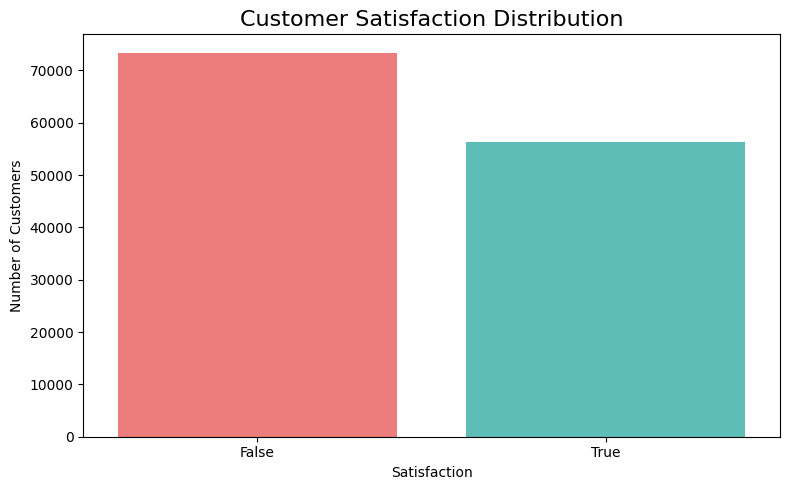

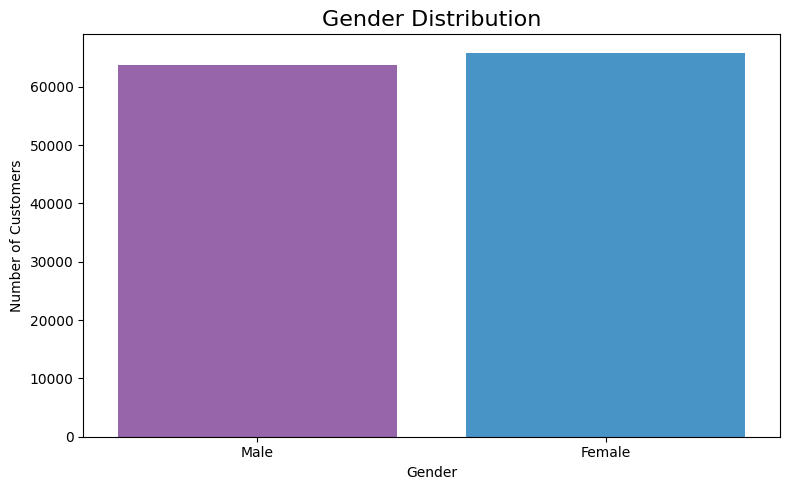

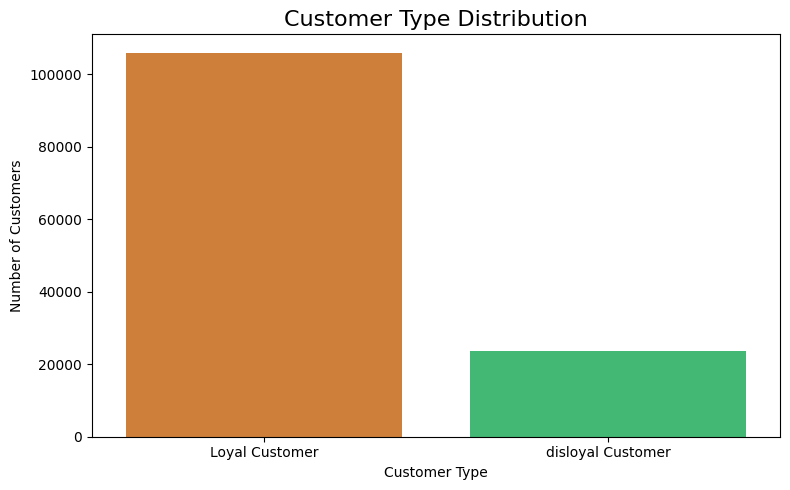

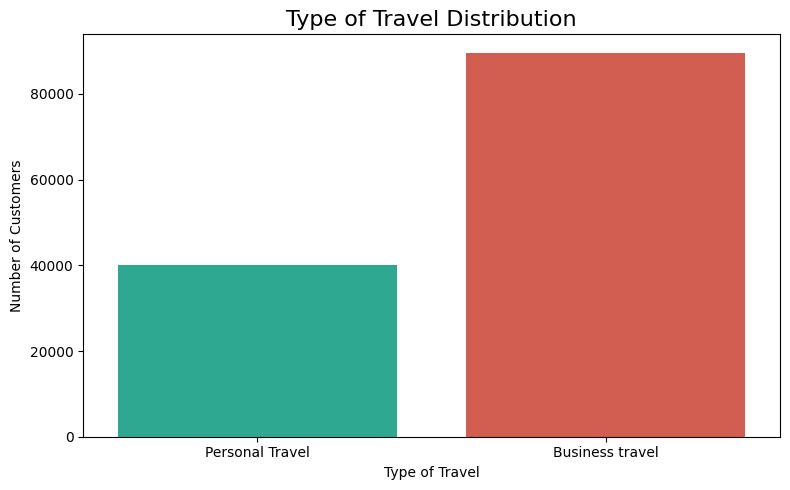

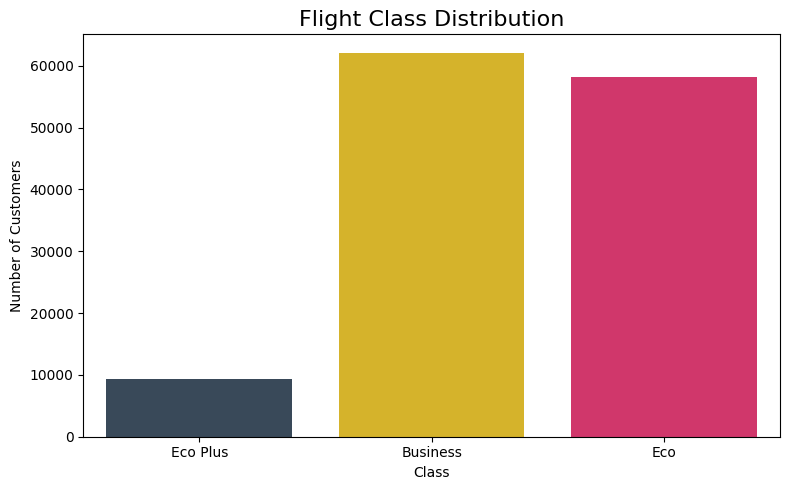

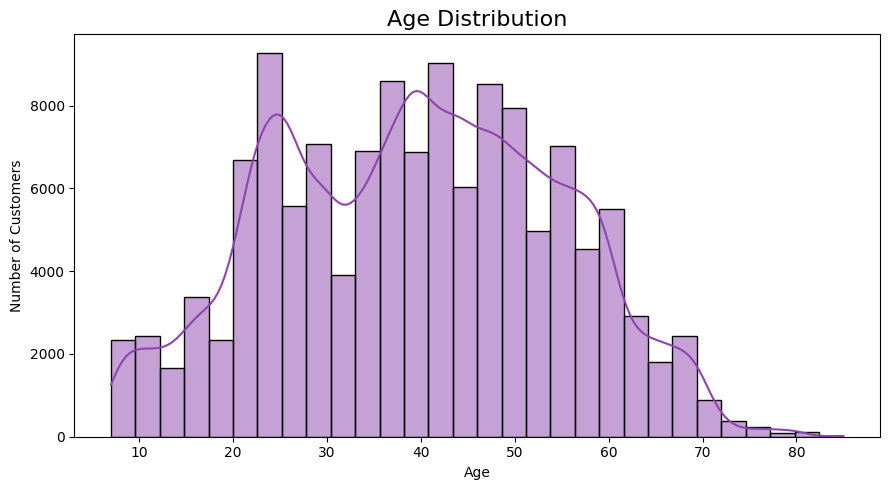

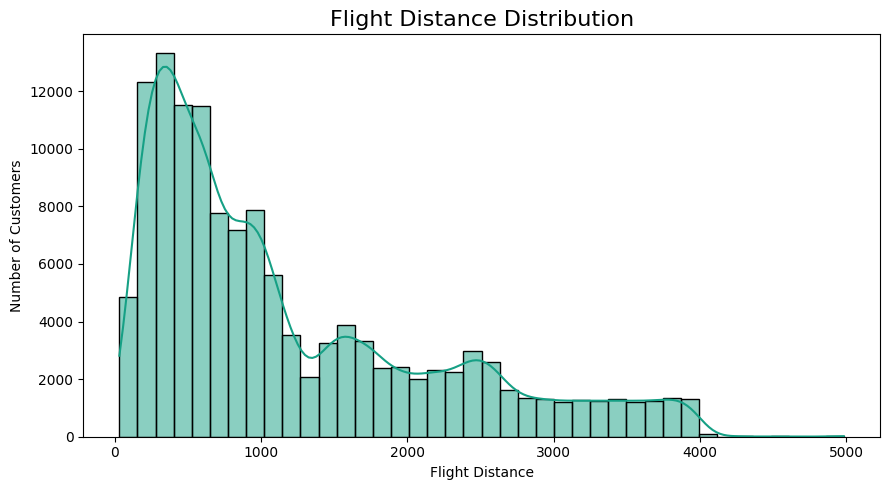

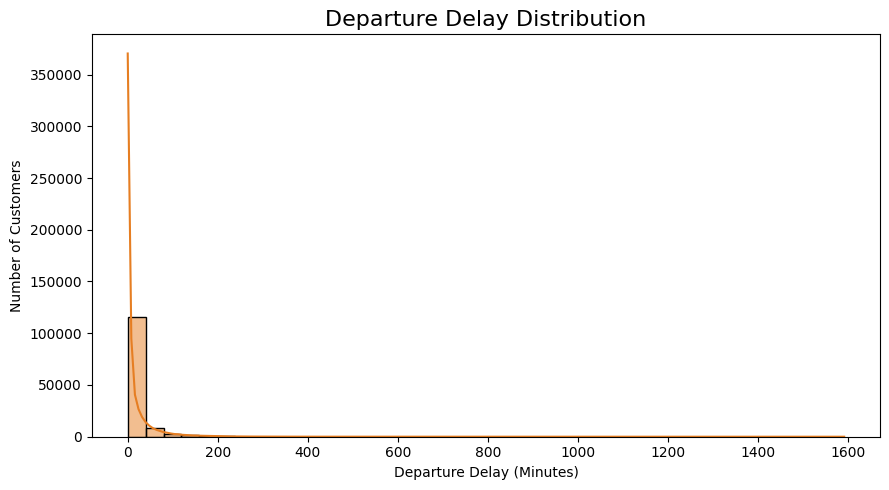

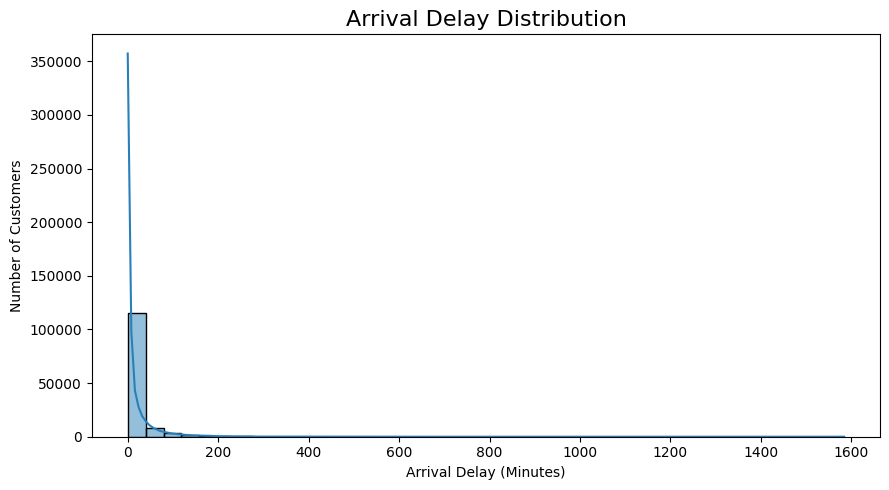

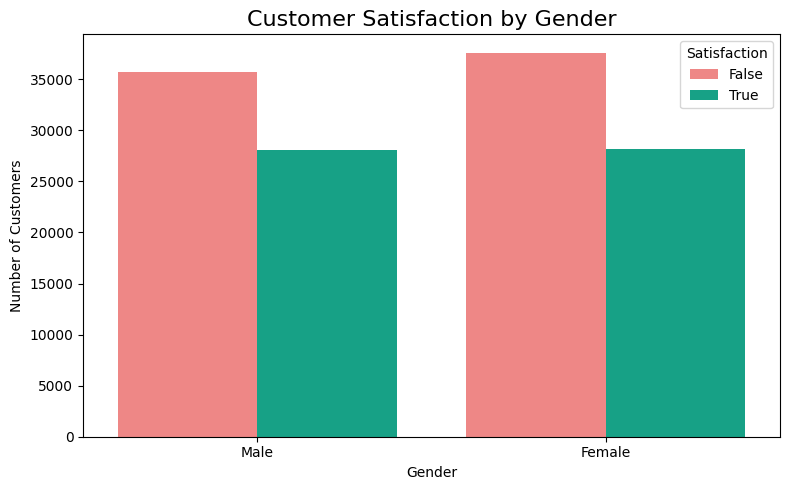

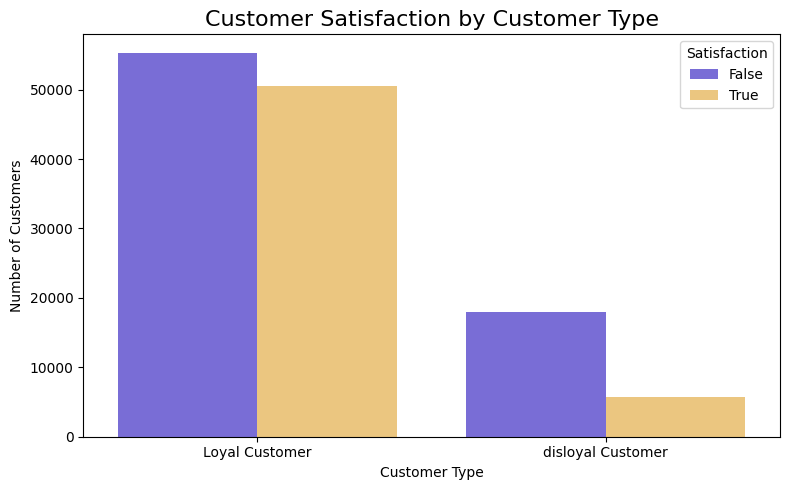

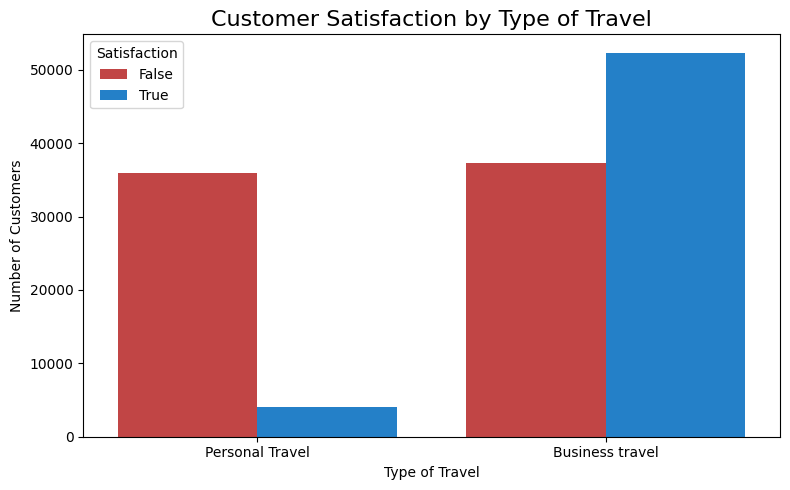

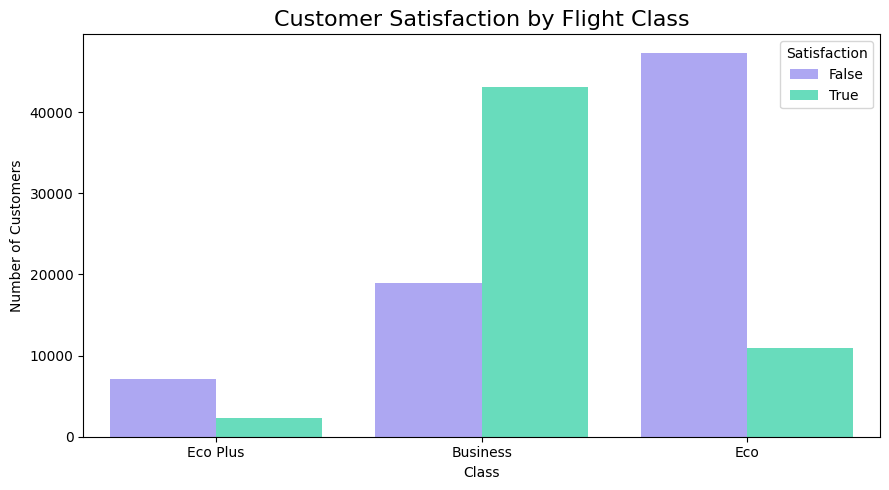

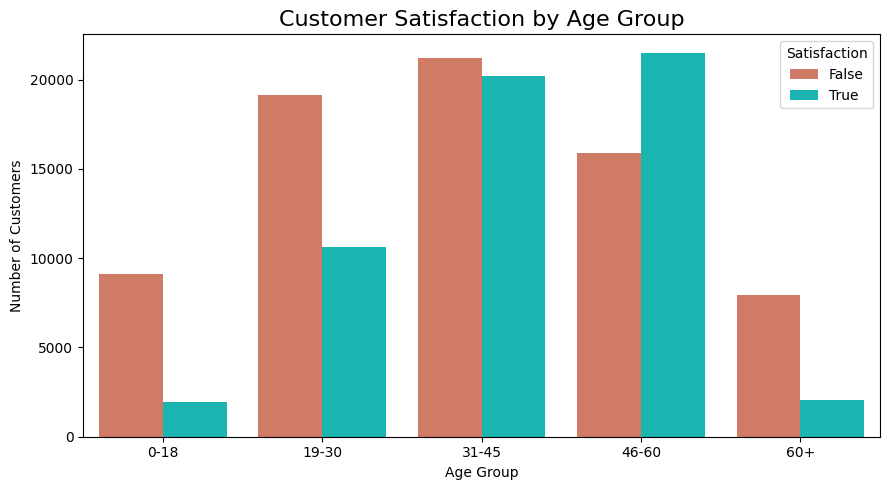

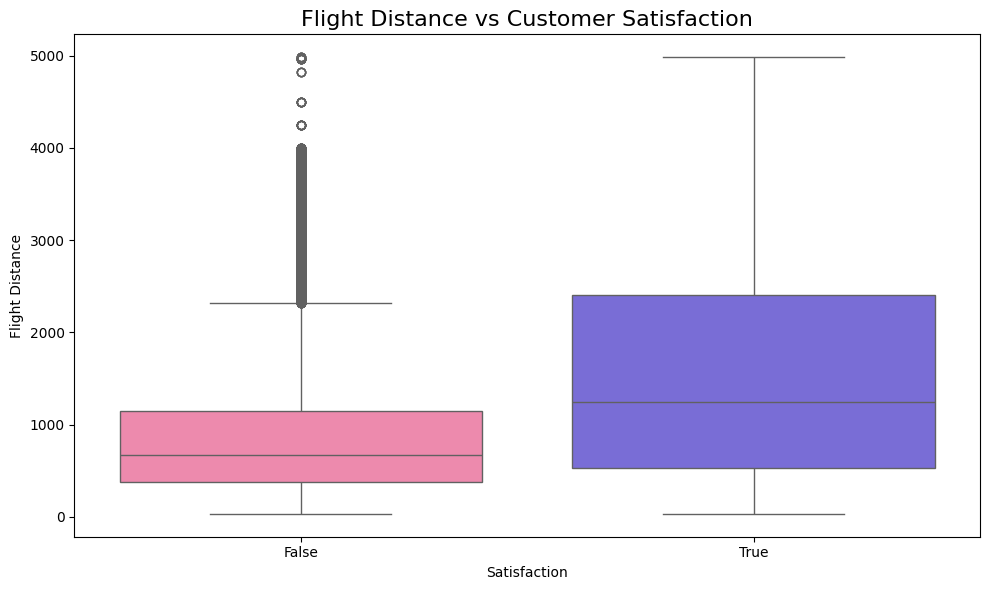

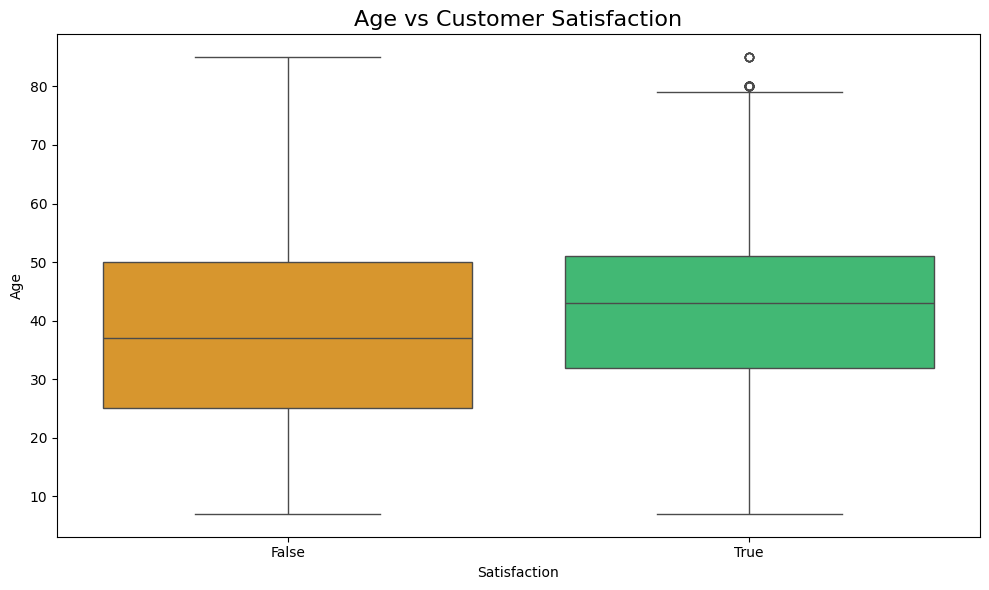

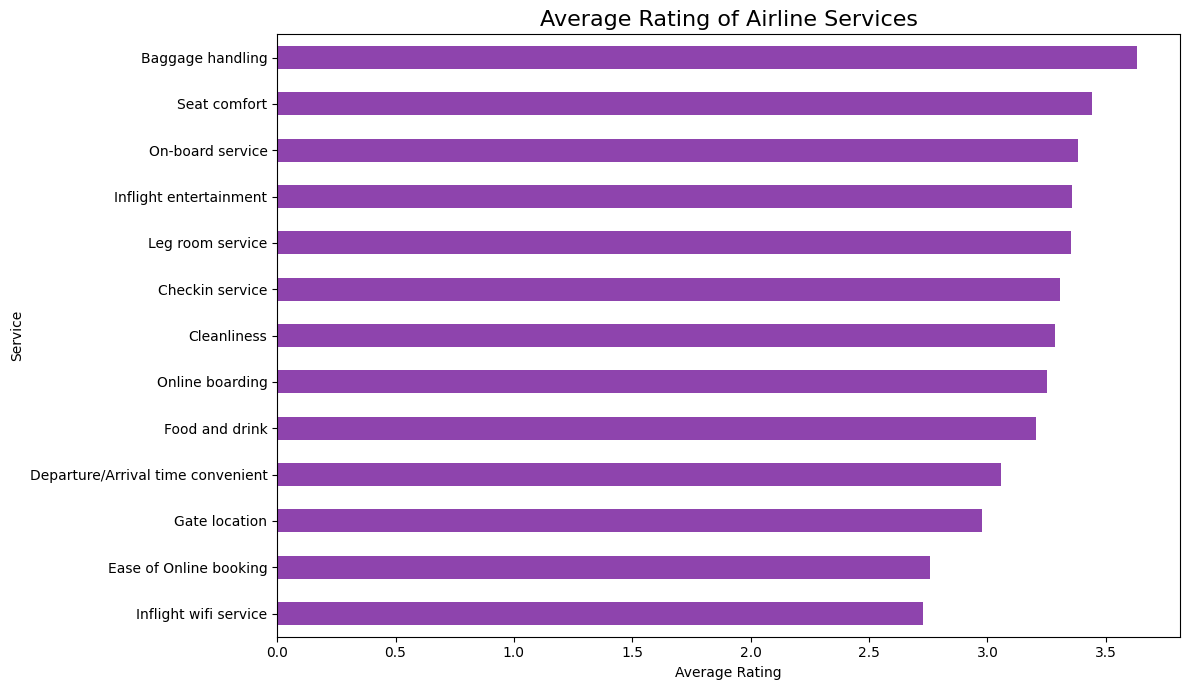

<Figure size 1200x800 with 0 Axes>

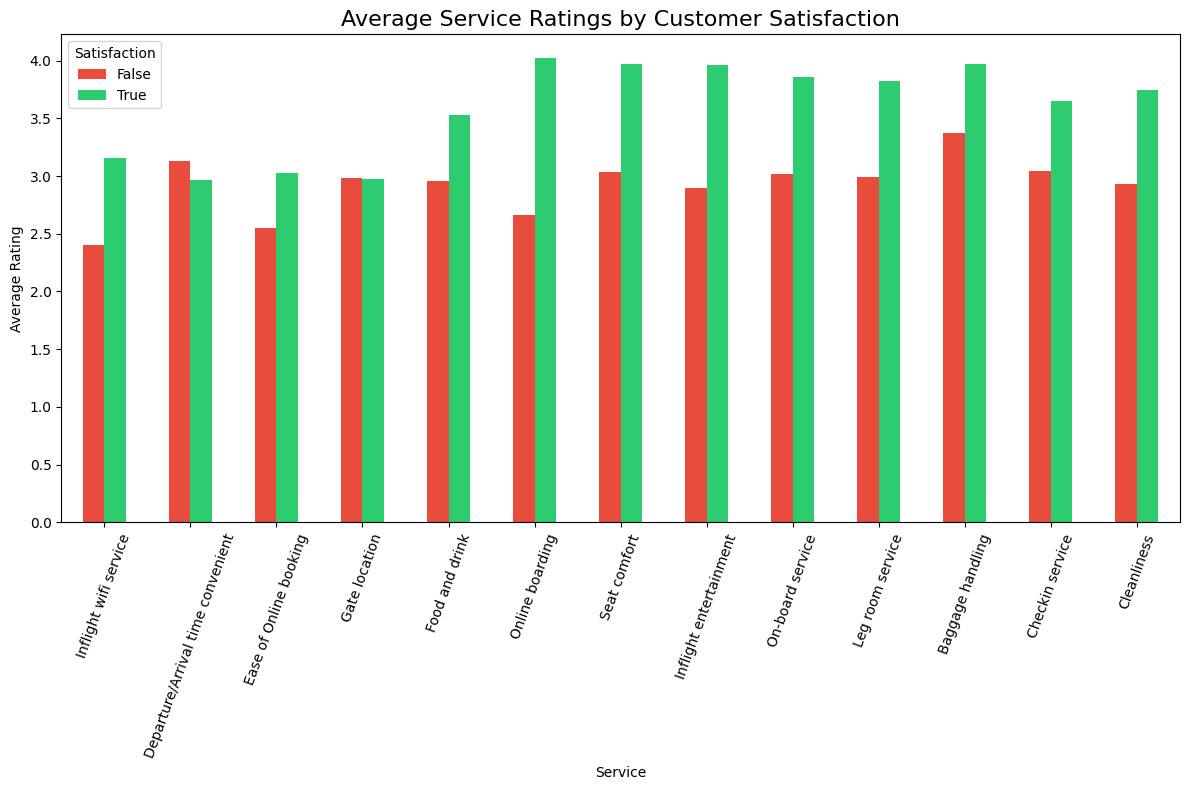

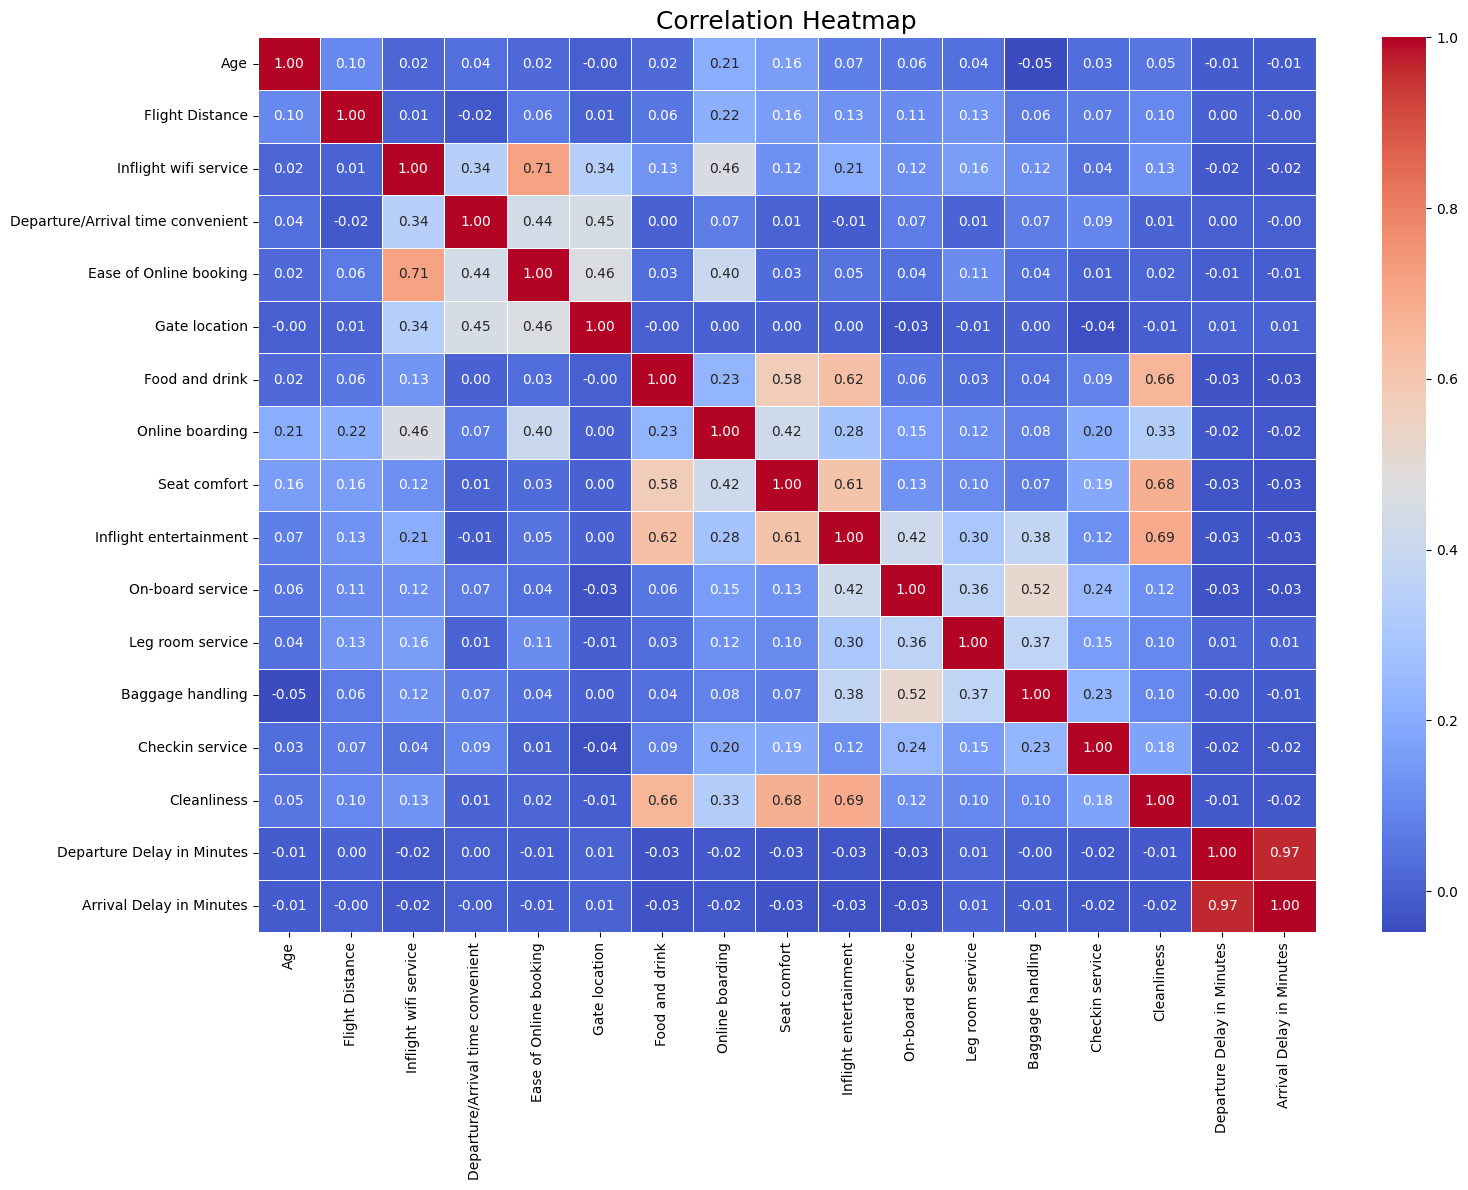

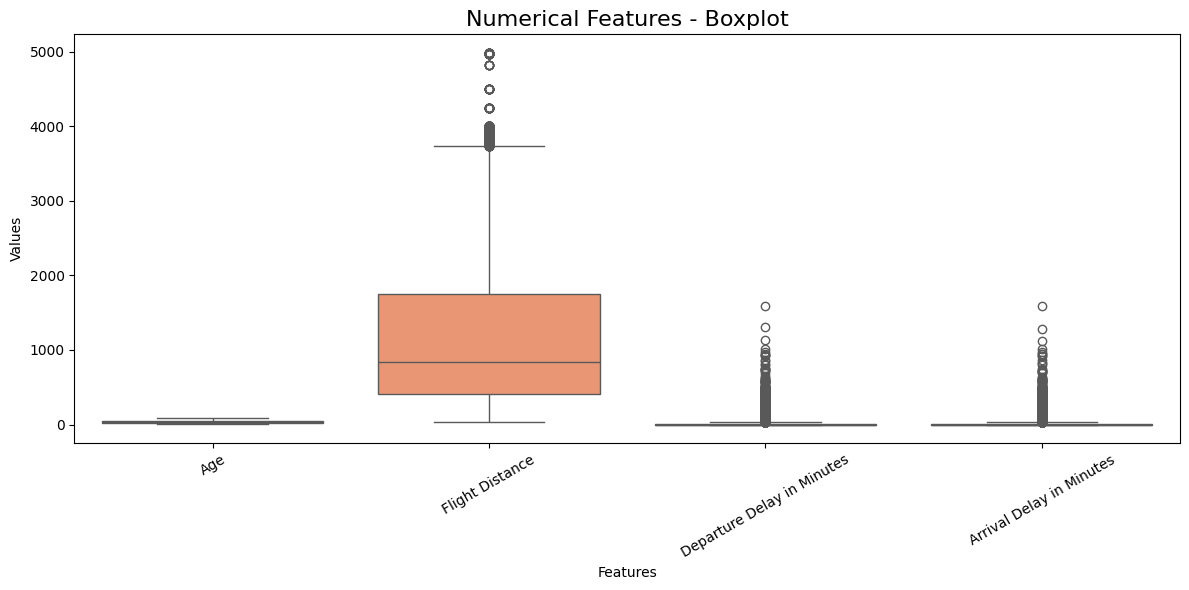


Satisfaction Percentage by Class:
satisfaction      False      True 
Class                             
Business      30.553315  69.446685
Eco           81.241289  18.758711
Eco Plus      75.373134  24.626866


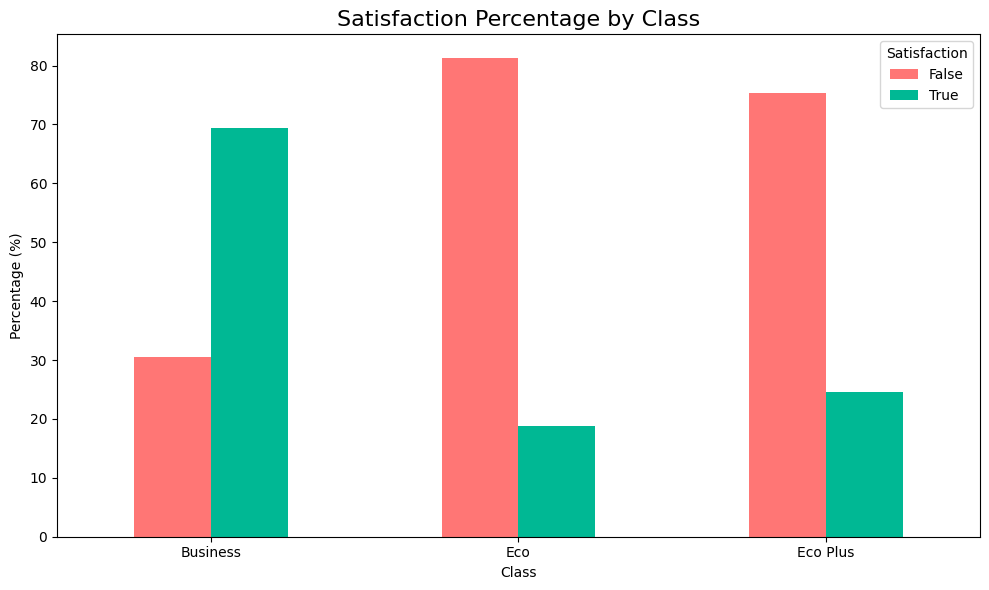


Satisfaction Percentage by Type of Travel:
satisfaction         False      True 
Type of Travel                       
Business travel  41.632288  58.367712
Personal Travel  89.873133  10.126867


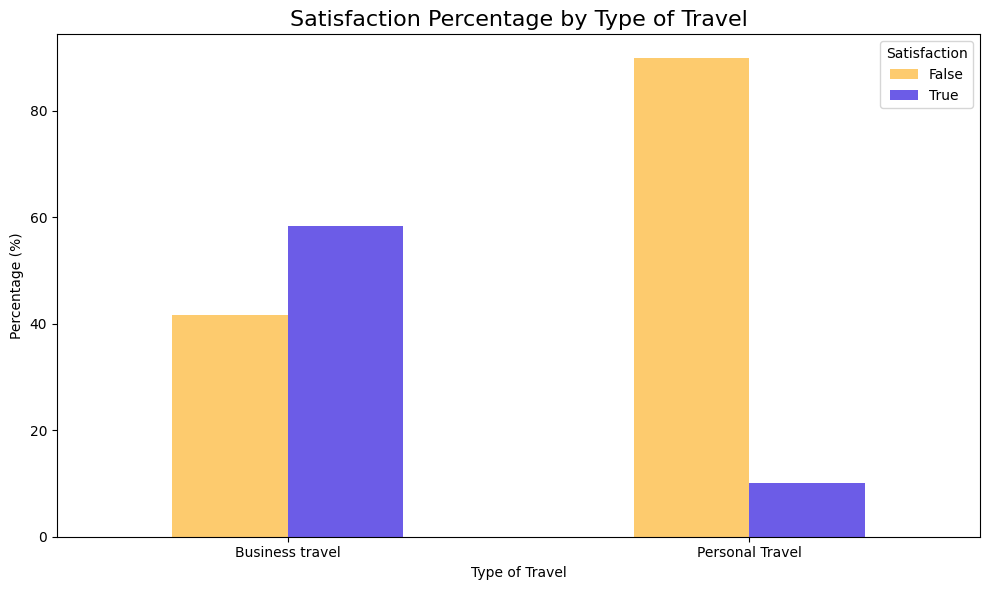

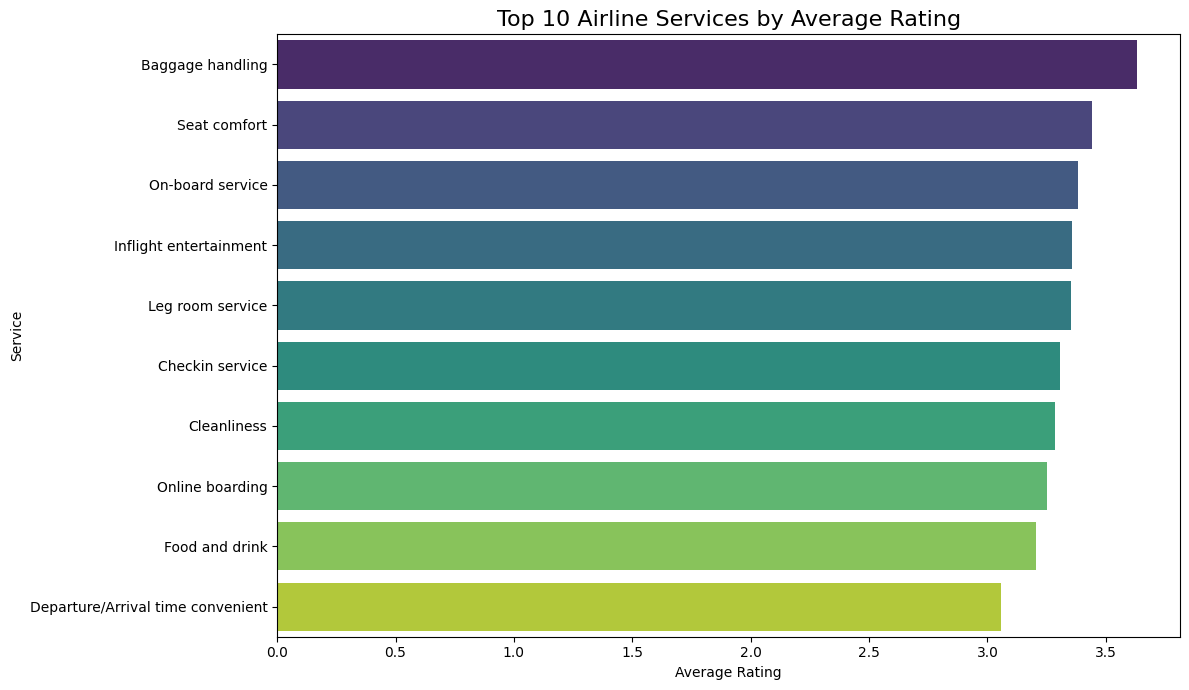


================ VISUALIZATION SUMMARY ================
Total Customers: 129487

Satisfaction Counts:
satisfaction
False    73225
True     56262
Name: count, dtype: int64

Average Age: 39.43
Average Flight Distance: 1190.21
Average Departure Delay: 14.64
Average Arrival Delay: 15.09

Average Service Ratings:
Inflight wifi service                2.728544
Ease of Online booking               2.756786
Gate location                        2.976909
Departure/Arrival time convenient    3.057349
Food and drink                       3.204685
Online boarding                      3.252720
Cleanliness                          3.286222
Checkin service                      3.306239
Leg room service                     3.351078
Inflight entertainment               3.358067
On-board service                     3.383204
Seat comfort                         3.441589
Baggage handling                     3.631886
dtype: float64



In [13]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ------------------------------------------------------------
# 2. BASIC INFORMATION
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ------------------------------------------------------------
# 3. REMOVE MISSING VALUES
# ------------------------------------------------------------

df = df.dropna()

print("\nShape after removing missing values:", df.shape)


# ============================================================
# 4. SATISFACTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="satisfaction",
    hue="satisfaction",
    palette=["#FF6B6B", "#4ECDC4"],
    legend=False
)

plt.title("Customer Satisfaction Distribution", fontsize=16)
plt.xlabel("Satisfaction")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 5. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette=["#9B59B6", "#3498DB"],
    legend=False
)

plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 6. CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer Type",
    hue="Customer Type",
    palette=["#E67E22", "#2ECC71"],
    legend=False
)

plt.title("Customer Type Distribution", fontsize=16)
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 7. TYPE OF TRAVEL
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Type of Travel",
    hue="Type of Travel",
    palette=["#1ABC9C", "#E74C3C"],
    legend=False
)

plt.title("Type of Travel Distribution", fontsize=16)
plt.xlabel("Type of Travel")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette=["#34495E", "#F1C40F", "#E91E63"],
    legend=False
)

plt.title("Flight Class Distribution", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 9. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True,
    color="#8E44AD"
)

plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 10. FLIGHT DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Flight Distance",
    bins=40,
    kde=True,
    color="#16A085"
)

plt.title("Flight Distance Distribution", fontsize=16)
plt.xlabel("Flight Distance")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 11. DEPARTURE DELAY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Departure Delay in Minutes",
    bins=40,
    kde=True,
    color="#E67E22"
)

plt.title("Departure Delay Distribution", fontsize=16)
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 12. ARRIVAL DELAY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Arrival Delay in Minutes",
    bins=40,
    kde=True,
    color="#2980B9"
)

plt.title("Arrival Delay Distribution", fontsize=16)
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 13. SATISFACTION BY GENDER
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="satisfaction",
    palette=["#FF7675", "#00B894"]
)

plt.title("Customer Satisfaction by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 14. SATISFACTION BY CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer Type",
    hue="satisfaction",
    palette=["#6C5CE7", "#FDCB6E"]
)

plt.title("Customer Satisfaction by Customer Type", fontsize=16)
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 15. SATISFACTION BY TYPE OF TRAVEL
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Type of Travel",
    hue="satisfaction",
    palette=["#D63031", "#0984E3"]
)

plt.title("Customer Satisfaction by Type of Travel", fontsize=16)
plt.xlabel("Type of Travel")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 16. SATISFACTION BY CLASS
# ============================================================

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Class",
    hue="satisfaction",
    palette=["#A29BFE", "#55EFC4"]
)

plt.title("Customer Satisfaction by Flight Class", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 17. AGE GROUP
# ============================================================

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "60+"]
)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Age Group",
    hue="satisfaction",
    palette=["#E17055", "#00CEC9"]
)

plt.title("Customer Satisfaction by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 18. FLIGHT DISTANCE VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="satisfaction",
    y="Flight Distance",
    hue="satisfaction",
    palette=["#FD79A8", "#6C5CE7"],
    legend=False
)

plt.title("Flight Distance vs Customer Satisfaction", fontsize=16)
plt.xlabel("Satisfaction")
plt.ylabel("Flight Distance")
plt.tight_layout()
plt.show()


# ============================================================
# 19. AGE VS SATISFACTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="satisfaction",
    y="Age",
    hue="satisfaction",
    palette=["#F39C12", "#2ECC71"],
    legend=False
)

plt.title("Age vs Customer Satisfaction", fontsize=16)
plt.xlabel("Satisfaction")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


# ============================================================
# 20. SERVICE RATINGS
# ============================================================

service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness"
]

service_mean = df[service_columns].mean().sort_values()

plt.figure(figsize=(12, 7))

service_mean.plot(
    kind="barh",
    color="#8E44AD"
)

plt.title("Average Rating of Airline Services", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Service")
plt.tight_layout()
plt.show()


# ============================================================
# 21. SERVICE RATINGS BY SATISFACTION
# ============================================================

service_satisfaction = df.groupby("satisfaction")[service_columns].mean().T

plt.figure(figsize=(12, 8))

service_satisfaction.plot(
    kind="bar",
    figsize=(12, 8),
    color=["#E74C3C", "#2ECC71"]
)

plt.title(
    "Average Service Ratings by Customer Satisfaction",
    fontsize=16
)

plt.xlabel("Service")
plt.ylabel("Average Rating")
plt.xticks(rotation=70)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 22. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()


# ============================================================
# 23. NUMERICAL FEATURES BOXPLOT
# ============================================================

numeric_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numeric_columns],
    palette="Set2"
)

plt.title("Numerical Features - Boxplot", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 24. SATISFACTION PERCENTAGE BY CLASS
# ============================================================

satisfaction_percentage = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

print("\nSatisfaction Percentage by Class:")
print(satisfaction_percentage)

satisfaction_percentage.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#FF7675", "#00B894"]
)

plt.title("Satisfaction Percentage by Class", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 25. SATISFACTION PERCENTAGE BY TYPE OF TRAVEL
# ============================================================

travel_percentage = pd.crosstab(
    df["Type of Travel"],
    df["satisfaction"],
    normalize="index"
) * 100

print("\nSatisfaction Percentage by Type of Travel:")
print(travel_percentage)

travel_percentage.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#FDCB6E", "#6C5CE7"]
)

plt.title("Satisfaction Percentage by Type of Travel", fontsize=16)
plt.xlabel("Type of Travel")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()


# ============================================================
# 26. TOP SERVICE RATINGS
# ============================================================

top_services = service_mean.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_services.values,
    y=top_services.index,
    hue=top_services.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Airline Services by Average Rating", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Service")
plt.tight_layout()
plt.show()


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n================ VISUALIZATION SUMMARY ================")

print("Total Customers:", len(df))

print("\nSatisfaction Counts:")
print(df["satisfaction"].value_counts())

print("\nAverage Age:", round(df["Age"].mean(), 2))

print(
    "Average Flight Distance:",
    round(df["Flight Distance"].mean(), 2)
)

print(
    "Average Departure Delay:",
    round(df["Departure Delay in Minutes"].mean(), 2)
)

print(
    "Average Arrival Delay:",
    round(df["Arrival Delay in Minutes"].mean(), 2)
)

print("\nAverage Service Ratings:")
print(service_mean)

print("\n========================================================")

## Feature engineering

Dataset Shape:
(129487, 23)

Columns:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction', 'Age Group']

First 5 Rows:
   Gender      Customer Type  Age   Type of Travel     Class  Flight Distance  \
0    Male     Loyal Customer   13  Personal Travel  Eco Plus              460   
1    Male  disloyal Customer   25  Business travel  Business              235   
2  Female     Loyal Customer   26  Business travel  Business             1142   
3  Female     Loyal Customer   25  Business travel  Business              562   
4    Male     Loyal Customer   61  Business travel  Business              214   

   Inflight wi

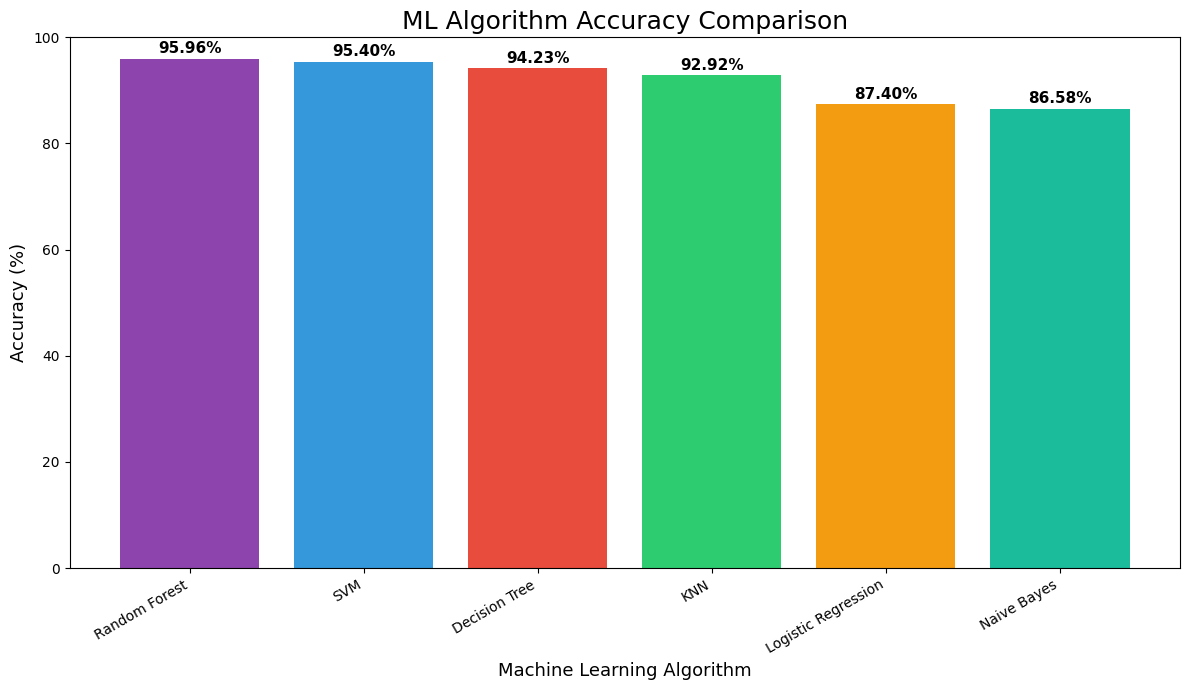

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

# Arrival Delay has some missing values in this dataset.
# Fill numerical missing values with median.

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


# Fill categorical missing values with mode

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


print("\nMissing values after treatment:")
print(df.isnull().sum().sum())


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("satisfaction", axis=1)

y = df["satisfaction"]


print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)


# ============================================================
# 6. LABEL ENCODING
# ============================================================

# Find categorical columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

print("\nCategorical Columns:")
print(categorical_columns.tolist())


# Create LabelEncoder

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    X[column] = le.fit_transform(X[column])

    label_encoders[column] = le


# Encode target column

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


print("\nEncoded X:")
print(X.head())

print("\nEncoded Target:")
print(y[:10])


# ============================================================
# 7. CHECK ENCODING
# ============================================================

print("\nTarget Classes:")

for i, class_name in enumerate(target_encoder.classes_):
    print(i, "=", class_name)


X = df.drop(
    columns=["satisfaction", "Age Group"]
)

y = df["satisfaction"]


print("X Shape:", X.shape)
print("y Shape:", y.shape)


# ============================================================
# 2. LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    X[column] = le.fit_transform(X[column])

    label_encoders[column] = le


# Encode target

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


print("\nEncoded X:")
print(X.head())

print("\nTarget Classes:")
print(target_encoder.classes_)


# ============================================================
# 3. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# ============================================================
# 4. FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nScaling completed successfully!")


# ============================================================
# 9. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("\nScaling completed.")


# ============================================================
# 10. CREATE ML MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB()
}


# ============================================================
# 11. TRAIN ALL MODELS
# ============================================================

results = {}

predictions = {}

for name, model in models.items():

    print("\n========================================")
    print("Training:", name)
    print("========================================")

    # Train model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test_scaled
    )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_percentage = accuracy * 100

    results[name] = accuracy_percentage

    predictions[name] = y_pred

    print(
        "Accuracy:",
        round(accuracy_percentage, 2),
        "%"
    )


# ============================================================
# 12. ACCURACY COMPARISON
# ============================================================

results_df = pd.DataFrame(
    list(results.items()),
    columns=[
        "Algorithm",
        "Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n\n========================================")
print("MODEL ACCURACY COMPARISON")
print("========================================")

print(
    results_df.to_string(index=False)
)


# ============================================================
# 13. BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n========================================")
print("BEST MODEL")
print("========================================")

print(
    "Algorithm:",
    best_model["Algorithm"]
)

print(
    "Accuracy:",
    round(best_model["Accuracy"], 2),
    "%"
)


# ============================================================
# 14. ACCURACY BAR CHART
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    results_df["Algorithm"],
    results_df["Accuracy"],
    color=[
        "#8E44AD",
        "#3498DB",
        "#E74C3C",
        "#2ECC71",
        "#F39C12",
        "#1ABC9C"
    ]
)

plt.title(
    "ML Algorithm Accuracy Comparison",
    fontsize=18
)

plt.xlabel(
    "Machine Learning Algorithm",
    fontsize=13
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(
    0,
    100
)


# Display accuracy on top of bars

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()




## THank you..pls upvote!!!!!!!!!!
